In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv"
)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df["temp_diff"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

df["power_proxy"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
)

In [4]:
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True
)

In [5]:
X = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

y = df["Machine failure"]

In [6]:
print(
    X.select_dtypes(include="object").columns
)

Index([], dtype='object')


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
preds = model.predict(X_test)

In [10]:
print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.93      0.79      0.86        68

    accuracy                           0.99      2000
   macro avg       0.96      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



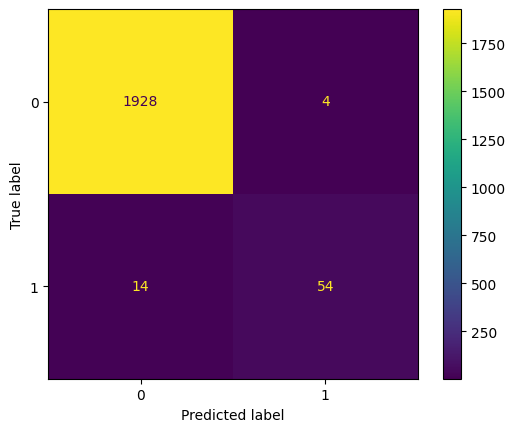

In [11]:
cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

importance.head(10)

power_proxy                0.251889
Torque [Nm]                0.189017
Rotational speed [rpm]     0.172043
temp_diff                  0.138413
Tool wear [min]            0.132412
Air temperature [K]        0.051433
Process temperature [K]    0.045646
Type_L                     0.010917
Type_M                     0.008230
dtype: float64

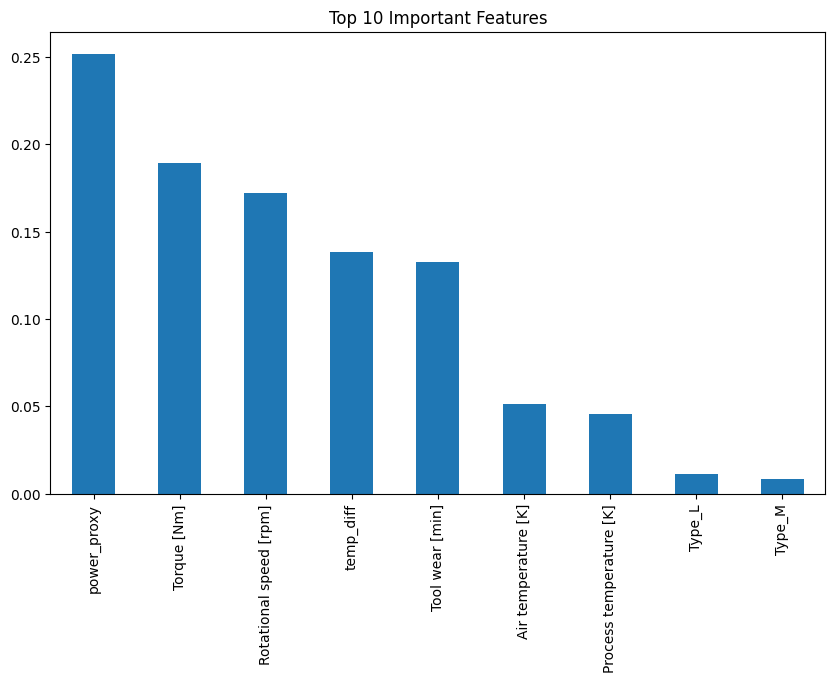

In [13]:
plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="bar"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()